# **Yaw Mode Analysis**

### Contents
1. ASD (Amplitude Spectral Density) plot with resonant frequency indication  
2. Magnitude transfer function plot \(|H(f)|\) with resonant frequency marker  
   - Isolated resonance peak visualization  
3. Lorentzian fitting of resonance peak  
   - Extraction of resonant frequency and quality factor \(Q\)  
4. Comparison between analytical and experimental responses

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import detrend, find_peaks, welch
from scipy.fft import rfft, rfftfreq
from scipy.optimize import curve_fit

#Load experimental yaw mode data
file_path = "path/data.lvm"
data = pd.read_csv(file_path, sep=r'\t', header=None, comment='#', engine='python')

#Assign column names
data.columns = ["time", "output", "input"]

#Extract time series and signals
time = data["time"].values
input_signal = data["input"].values
output_signal = data["output"].values

#Remove DC offset and slow drift from output signal
output_signal = detrend(output_signal)

#Define sampling parameters
dt = time[1] - time[0]      #Sampling interval
fs = 1 / dt                 #Sampling frequency
n = len(time)               #Number of samples

Resonant Frequency = 1.091255 Hz


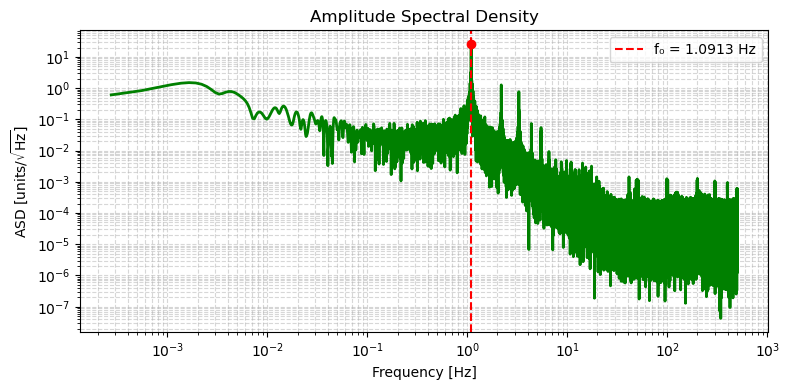

In [26]:
#Amplitude Spectral Density analysis
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, find_peaks

#Amplitude Spectral Density using Welch Method
freqs, psd = welch(output_signal, fs=fs, window='hann', nperseg=n, nfft=4*n, detrend='constant')
asd = np.sqrt(psd)

#Detect resonance peak
peaks, _ = find_peaks(asd, prominence=np.max(asd) * 0.02)

#Identify dominant resonance peak
peak_index = peaks[np.argmax(asd[peaks])]

#Extract resonant frequency and ASD amplitude
resonant_freq = freqs[peak_index]
resonant_asd = asd[peak_index]

#Display resonant frequency
print(f"Resonant Frequency = {resonant_freq:.6f} Hz")

#Plot ASD
plt.figure(figsize=(8,4))
plt.loglog(freqs[1:], asd[1:], color='green', linewidth=2)
plt.axvline(resonant_freq, color='red', linestyle='--', label=f'f₀ = {resonant_freq:.4f} Hz')
plt.scatter(resonant_freq, resonant_asd, color='red', zorder=5)
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"ASD [units/$\sqrt{\mathrm{Hz}}$]")
plt.title("Amplitude Spectral Density")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Resonant Frequency = 1.090708 Hz


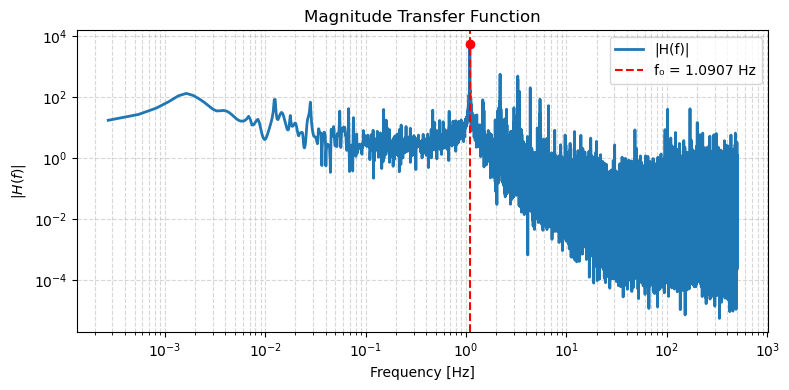

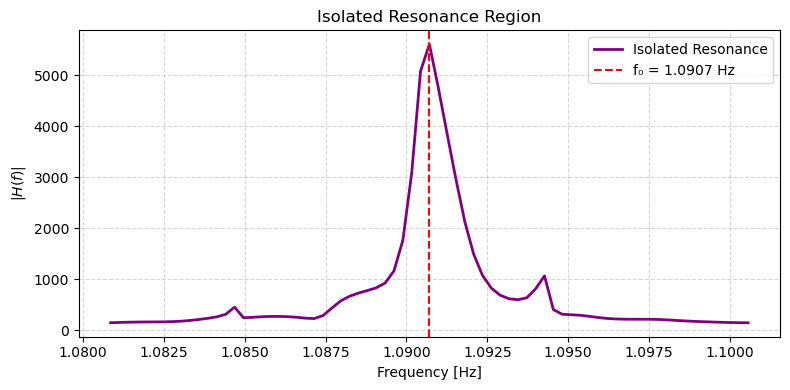

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, csd, find_peaks

#Compute input PSD
freqs, psd_input = welch(input_signal, fs=fs, window='hann', nperseg=n, nfft=4*n, detrend='constant')

#Compute cross-spectral density
_, cross_spectrum = csd(output_signal, input_signal, fs=fs, window='hann', nperseg=n, nfft=4*n, detrend='constant')

#Compute transfer function
transfer_function = cross_spectrum / psd_input
magnitude_tf = np.abs(transfer_function)

#Detect resonance peak
peaks_tf, _ = find_peaks(magnitude_tf, prominence=np.max(magnitude_tf) * 0.02)

#Identify dominant resonance peak
peak_index_tf = peaks_tf[np.argmax(magnitude_tf[peaks_tf])]

#Extract resonance parameters
resonant_freq_tf = freqs[peak_index_tf]
peak_magnitude_tf = magnitude_tf[peak_index_tf]

#Display resonant frequency
print(f"Resonant Frequency = {resonant_freq_tf:.6f} Hz")

#Isolate resonance region
bandwidth = 0.01
lower_bound = resonant_freq_tf - bandwidth
upper_bound = resonant_freq_tf + bandwidth
mask = (freqs >= lower_bound) & (freqs <= upper_bound)
freqs_peak_region = freqs[mask]
tf_peak_region = magnitude_tf[mask]

#Plot magnitude transfer function
plt.figure(figsize=(8,4))
plt.loglog(freqs[1:], magnitude_tf[1:], linewidth=2, label='|H(f)|')
plt.axvline(resonant_freq_tf, color='red', linestyle='--', label=f'f₀ = {resonant_freq_tf:.4f} Hz')
plt.scatter(resonant_freq_tf, peak_magnitude_tf, color='red', zorder=5)
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|H(f)|$")
plt.title("Magnitude Transfer Function")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#Plot isolated resonance peak
plt.figure(figsize=(8,4))
plt.plot(freqs_peak_region, tf_peak_region, linewidth=2, color='purple', label='Isolated Resonance')
plt.axvline(resonant_freq_tf, color='red', linestyle='--', label=f'f₀ = {resonant_freq_tf:.4f} Hz')
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|H(f)|$")
plt.title("Isolated Resonance Region")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Resonant Frequency = 1.090790 ± 0.000021 Hz
Gamma (FWHM) = 0.001555 ± 0.000060 Hz
Quality Factor Q = 2203.95 ± 84.38


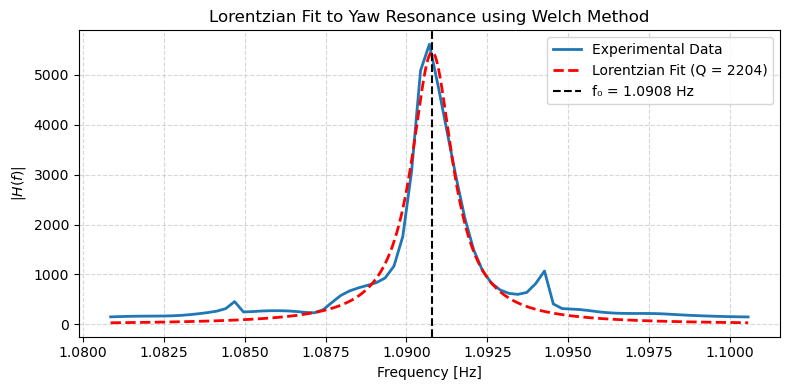

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#Define Lorentzian model
def lorentzian(f, A, f0, gamma):
    return A / (1 + ((2 * (f - f0) / gamma)**2))

#Estimate initial fitting parameters
A_guess = np.max(tf_peak_region)
f0_guess = freqs_peak_region[np.argmax(tf_peak_region)]

#Estimate linewidth using Full Width at Half Maximum (FWHM)
half_max = A_guess / 2
indices_above_half = np.where(tf_peak_region >= half_max)[0]

if len(indices_above_half) >= 2:
    gamma_guess = (freqs_peak_region[indices_above_half[-1]] - freqs_peak_region[indices_above_half[0]])/2
else:
    gamma_guess = 0.004

#Initial parameter vector
initial_guesses = [A_guess, f0_guess, gamma_guess]

#Perform Lorentzian fitting
popt, pcov = curve_fit(lorentzian, freqs_peak_region, tf_peak_region, p0=initial_guesses)

#Extract fitted parameters
A_fit, f0_fit, gamma_fit = popt

#Compute parameter uncertainties
perr = np.sqrt(np.diag(pcov))
A_err, f0_err, gamma_err = perr

#Compute quality factor using Lorentzian FWHM convention
Q_factor = np.pi*f0_fit / gamma_fit

#Propagate uncertainty in Q
Q_error = Q_factor * np.sqrt((f0_err / f0_fit)**2 + (gamma_err / gamma_fit)**2)

#Generate smooth fitted curve
f_fit = np.linspace(freqs_peak_region[0], freqs_peak_region[-1], 2000)
fit_vals = lorentzian(f_fit, *popt)

#Display fitted parameters
print(f"\nResonant Frequency = {f0_fit:.6f} ± {f0_err:.6f} Hz")
print(f"Gamma (FWHM) = {gamma_fit:.6f} ± {gamma_err:.6f} Hz")
print(f"Quality Factor Q = {Q_factor:.2f} ± {Q_error:.2f}")

#Plot 
plt.figure(figsize=(8,4))
plt.plot(freqs_peak_region, tf_peak_region, linewidth=2, label='Experimental Data')
plt.plot(f_fit, fit_vals, 'r--', linewidth=2, label=f'Lorentzian Fit (Q = {Q_factor:.0f})')
plt.axvline(f0_fit, color='black', linestyle='--', label=f'f₀ = {f0_fit:.4f} Hz')
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|H(f)|$")
plt.title("Lorentzian Fit to Yaw Resonance using Welch Method")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Experimental Resonant Frequency = 1.090982 Hz
Theoretical Resonant Frequency = 1.106074 Hz


C:\Users\shrey\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


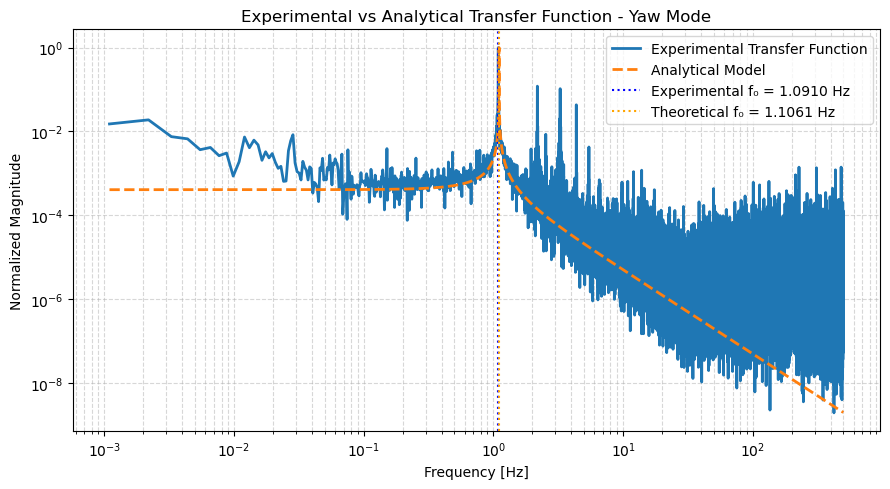

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, csd, find_peaks, ss2tf, bode, TransferFunction

#Compute input PSD
freqs, psd_input = welch(input_signal, fs=fs, window='hann', nperseg=n, detrend='constant')

#Compute cross-spectral density
_, cross_spectrum = csd(output_signal, input_signal, fs=fs, window='hann', nperseg=n, detrend='constant')

#Compute experimental transfer function
transfer_function = cross_spectrum / psd_input

#Magnitude transfer function
magnitude_tf = np.abs(transfer_function)

#Normalize experimental transfer function
magnitude_tf_norm = magnitude_tf / np.max(magnitude_tf)

#Detect resonance peak
peaks_tf, _ = find_peaks(magnitude_tf, prominence=np.max(magnitude_tf) * 0.02)

#Identify dominant resonance peak
peak_index_tf = peaks_tf[np.argmax(magnitude_tf[peaks_tf])]

#Extract experimental resonance frequency
resonant_freq_tf = freqs[peak_index_tf]

print(f"Experimental Resonant Frequency = {resonant_freq_tf:.6f} Hz")

#Define physical parameters
g = 9.81                 #Acceleration due to gravity [m/s^2]
l = 0.6                  #Wire length [m]
m = 0.102                #Mass [kg]
I_z = 22.7e-6            #Yaw moment of inertia [kg.m^2]
w = 0.007/2              #Horizontal offset in X direction [m]
t = 0.0508/2             #Vertical offset in Y direction [m]
d = 2*t                  #Offset in Z direction

#Construct state-space matrices for yaw motion
A = np.array([[0, 1],
              [-((t**2 + w**2) * m * g) / (I_z * l), 0]])

B = np.array([[0],
              [1 / I_z]])

C = np.array([[1, 0]])

D = np.array([[0]])

#Convert state-space model to transfer function
num, den = ss2tf(A, B, C, D)
analytical_tf = TransferFunction(num[0], den)

#Convert frequency axis from Hz to rad/s
w_rad = 2 * np.pi * freqs

#Avoid singularity at zero frequency
w_rad[w_rad == 0] = 1e-6

#Compute theoretical resonance frequency
omega_n = np.sqrt(((t**2 + w**2) * m * g) / (I_z * l))
f_n = omega_n / (2 * np.pi)

print(f"Theoretical Resonant Frequency = {f_n:.6f} Hz")

#Compute analytical transfer function magnitude
_, mag_analytical, _ = bode(analytical_tf, w=w_rad)

#Convert magnitude from dB to linear scale
mag_model = 10**(mag_analytical / 20)

#Normalize analytical transfer function
mag_model_norm = mag_model / np.max(mag_model)

#Plot analytical and experimental transfer functions
plt.figure(figsize=(9,5))
plt.loglog(freqs[1:], magnitude_tf_norm[1:], linewidth=2, label='Experimental Transfer Function')
plt.loglog(freqs[1:], mag_model_norm[1:], '--', linewidth=2, label='Analytical Model')
plt.axvline(resonant_freq_tf, color='blue', linestyle=':', label=f'Experimental f₀ = {resonant_freq_tf:.4f} Hz')
plt.axvline(f_n, color='orange', linestyle=':', label=f'Theoretical f₀ = {f_n:.4f} Hz')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized Magnitude")
plt.title("Experimental vs Analytical Transfer Function - Yaw Mode")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()